# Figures

In [73]:
library(tidyverse)
source("../scripts/00_R_presets.R")

## Figure 1: Assembly QC

Subplots:
A) Chromosome overview
B) QC Beesplot

In [74]:
hprc <- read_tsv("../../doc/tables/qc_hprc_table.tsv", show_col_types = F ) %>% 
    mutate(source = "hprc")
samples <- read_tsv("../../doc/tables/qc_samples_table.tsv", show_col_types = F) %>%
    mutate(source = "samples")


dt_qc <- bind_rows(hprc, samples) %>%
    filter(haplotype != "both") %>%
    filter(!(metric %in% c("qv")))
head(dt_qc)
tail(dt_qc)

metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<lgl>
length,2.947895e+09,haplotype1,phased_hprc,HG002,hprc,NA
ref_covered,9.075000e-01,haplotype1,phased_hprc,HG002,hprc,NA
asm_covered,9.653000e-01,haplotype1,phased_hprc,HG002,hprc,NA
length,3.051530e+09,haplotype2,phased_hprc,HG002,hprc,NA
ref_covered,9.415000e-01,haplotype2,phased_hprc,HG002,hprc,NA
asm_covered,9.686000e-01,haplotype2,phased_hprc,HG002,hprc,NA


metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<lgl>
MSC,0.05221773,haplotype1,phased_verkko,T2T17,samples,NA
MSC,0.01556011,haplotype2,phased_verkko,T2T17,samples,NA
MSC,0.05290991,haplotype1,phased_verkko,T2T18,samples,NA
MSC,0.01533861,haplotype2,phased_verkko,T2T18,samples,NA
MSC,0.05321446,haplotype1,phased_verkko,T2T19,samples,NA
MSC,0.01619691,haplotype2,phased_verkko,T2T19,samples,NA


In [75]:
metric_labels <- c(
    "length" = "Assembly Length (Mb)",
    "ref_covered" = "Reference Covered (%)",
    "asm_covered" = "Assembly Covered (%)",
    "inter-chromosomal_misjoins" = "Inter-chrom. Misjoins",
    "intra-chromosomal_gaps" = "Intra-chrom. Gaps",
    "candidate_inversions_in_the_middle" = "Inversions (Middle)",
    "candidate_inversions_at_contig_ends" = "Inversions (Ends)",
    "n_T2T" = "n T2T Chrom.",
    "total_n_count" = "Total N Count",
    "total_gaps" = "Total Gaps",
    "n_contigs" = "Number of Contigs",
    "n_contigs_over_10mb" = "n Contigs >10 Mb",
    "genome_completeness" = "Completeness (%)",
    "MMC" = "MMC (%)",
    "MSC" = "MSC (%)"
)

source_labels <- c(
    "hprc" = "HPRC",
    "samples" = "Samples"
)

haplotype_labels <- c(
    "haplotype1" = "Hap 1",
    "haplotype2" = "Hap 2"
)

# Update dt_qc with renamed fields
dt_qc_u <- dt_qc %>%
    mutate(
        metric = recode(metric, !!!metric_labels),
        source = recode(source, !!!source_labels),
        haplotype = recode(haplotype, !!!haplotype_labels)
    )

head(dt_qc)

metric,value,haplotype,asm_method,asm_name,source,chromosome
<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<lgl>
length,2.947895e+09,haplotype1,phased_hprc,HG002,hprc,NA
ref_covered,9.075000e-01,haplotype1,phased_hprc,HG002,hprc,NA
asm_covered,9.653000e-01,haplotype1,phased_hprc,HG002,hprc,NA
length,3.051530e+09,haplotype2,phased_hprc,HG002,hprc,NA
ref_covered,9.415000e-01,haplotype2,phased_hprc,HG002,hprc,NA
asm_covered,9.686000e-01,haplotype2,phased_hprc,HG002,hprc,NA


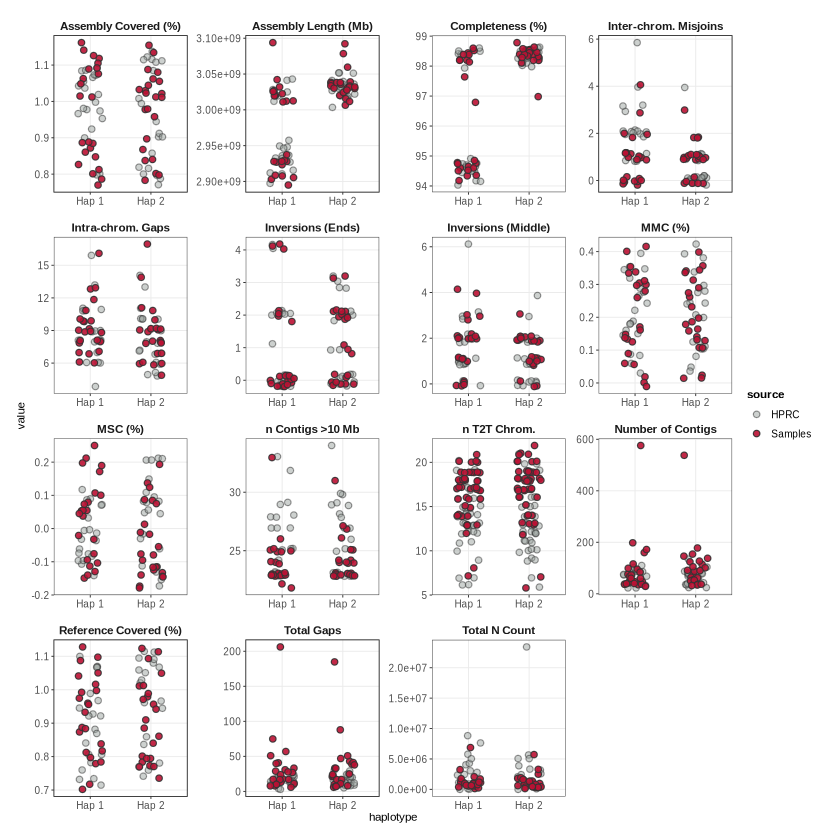

In [76]:
p_qc_beesplot_full <- ggplot(dt_qc_u, aes(x = haplotype, y = value, fill = source, alpha = source)) +
    geom_jitter(width = 0.2, height = 0.2, shape = 21, size = 1.5, colour = "grey20") +
    scale_fill_manual(values = col_source) +
    scale_alpha_manual(values = c("HPRC" = 0.5, "Samples" = 0.9)) +
    facet_wrap(~metric, scales = "free")

ggsave("../../doc/figures/qc_beesplot_full.png", p_qc_beesplot_full, width = 16*0.7, height = 9*0.7)
p_qc_beesplot_full

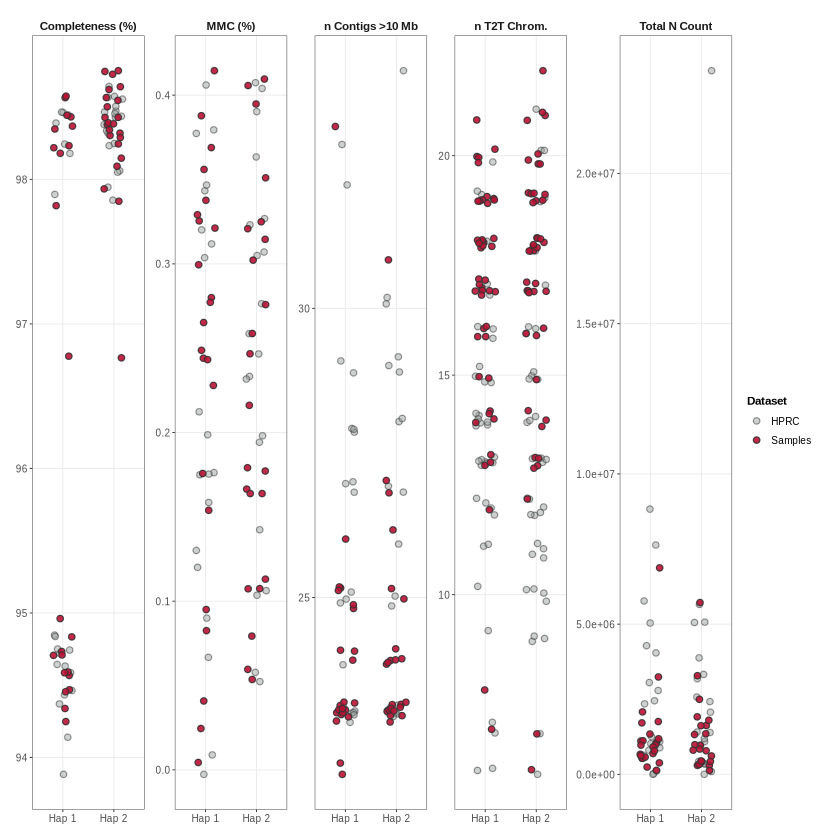

In [77]:
selection <- c(
    "n T2T Chrom.",
    "Total N Count",
    "n Contigs >10 Mb",
    "Completeness (%)",
    "MMC (%)"
    )
p_qc_beesplot <- ggplot(dt_qc_u %>% filter(metric %in% selection), aes(x = haplotype, y = value, fill = source, alpha = source)) +
    geom_jitter(width = 0.2, height = 0.2, shape = 21, size = 1.5, colour = "grey20") +
    scale_fill_manual(values = col_source) +
    scale_alpha_manual(values = c("HPRC" = 0.5, "Samples" = 0.9)) +
    facet_wrap(~metric, scales = "free", nrow = 1) +
    labs(x = NULL, y = NULL, fill = "Dataset", alpha = "Dataset")


ggsave("../../doc/figures/fig1_B_qc_beesplot.png", p_qc_beesplot, width = 7 , height = 1.5)
p_qc_beesplot

## Chromosome plots

## Figure 1A: Chromosome Ideogram

Using RIdeogram to create chromosome-level visualization

In [ ]:
# Install RIdeogram if needed
# install.packages("RIdeogram")

library(RIdeogram)

# RIdeogram requires specific data formats:
# 1. Karyotype file: chromosome, start, end (and optionally: CE_start, CE_end for centromere)
# 2. Data file: chromosome, start, end, value (for overlays)

In [ ]:
# Create karyotype data from reference FAI file
fai_file <- "../../data/ref/T2T-CHM13.v2.fasta.fai"

karyotype <- read_tsv(fai_file, 
    col_names = c("Chr", "End", "offset", "linebases", "linewidth", "qualoffset"),
    col_types = "cnnnnn",
    show_col_types = FALSE) %>%
    filter(Chr != "chrM") %>%
    mutate(Start = 1) %>%
    select(Chr, Start, End) %>%
    # Optionally add centromere positions if you have them
    # mutate(CE_start = NA, CE_end = NA) %>%
    arrange(Chr)

head(karyotype)
nrow(karyotype)

In [ ]:
# Example: Load your data to overlay on chromosomes
# This could be gaps, telomeres, or other features
# Format: Chr, Start, End, Value (or Type for categorical data)

# Example with gaps data
gap_data <- read_tsv("../../assembly/qc/phased_verkko/TUE_02_03UL_old/gap_stats.both.n_regions.bed",
                     col_names = c("contig", "Start", "End", "label", "length"),
                     col_types = "cddcd",
                     show_col_types = FALSE) %>%
    # You'll need to map contigs to chromosomes using your colors file
    mutate(Chr = "chr1", Value = 1) %>%  # Placeholder - needs actual mapping
    select(Chr, Start, End, Value)

head(gap_data)

In [ ]:
# Create basic ideogram
ideogram(karyotype = karyotype, 
         output = "../../doc/figures/fig1_A_ideogram.svg")

# With data overlay (heatmap style)
# ideogram(karyotype = karyotype, 
#          overlaid = gap_data,
#          output = "../../doc/figures/fig1_A_ideogram_with_data.svg")

# RIdeogram outputs SVG files that can be converted to PNG if needed
# You can customize colors, add labels, etc.